<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/Kalyani_AR_AK_analyst_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
df = pd.read_excel('/content/drive/MyDrive/Kalyani STUDY PATIENT.xlsx')

In [2]:
df.columns

Index(['IP NUMBER ', 'NAME ', 'AGE', 'SEX', 'DIAGNOSIS', 'KH', 'KV', 'AX',
       'AL', 'ACD', 'LT', 'V/A PRE OP', 'POD 1 DAY V/A', 'SPH', 'CYL', 'AXIS',
       'POD 1 DAY  AR ', 'POD 6 WEEK V/A ', 'SPH ', 'CYL.1', 'AXIS.1',
       'POD 6 WEEK   AR ', 'POD 3 MONTH V/A', 'SPH.1', 'CYL ', 'AXIS.2',
       'POD 3  MONTH    AR'],
      dtype='object')

In [3]:
df.head()

,IP NUMBER,NAME,AGE,SEX,DIAGNOSIS,KH,KV,AX,AL,ACD,...,POD 6 WEEK V/A,SPH,CYL.1,AXIS.1,POD 6 WEEK AR,POD 3 MONTH V/A,SPH.1,CYL,AXIS.2,POD 3 MONTH AR
0,2682458,NAGAMMA,54,F,LE MC,46.50,47.25,155,22.65,2.76,...,6\12,0.25,-1.25,100.0,+0.25/-1.25/100,6\9,0.5,-1.0,65.0,+0.50/-1.00/65
1,2682462,GOWRAMMA,63,F,LE MC,46.75,48.00,80,21.90,1.99,...,6\18,0.75,-2.00,90.0,+0.75/-2.00/90,6\12,0.5,-2.0,80.0,+0.50/-2.00/80
2,2682451,SUNDRAMMA,78,F,RE BROWN CATARACT,44.00,44.25,20,22.91,3.08,...,6\24,-1.5,-1.00,140.0,-1.50/-1.00/140,NaN,NaN,NaN,NaN,NaN
3,2683506,KUNNABASAMMA,71,F,RE NS II + PSC,45.25,45.75,120,22.32,3.48,...,6\18,-0.5,-0.75,140.0,-0.5/-0.75/140,6\9,-0.5,-0.5,150.0,-0.5/-0.50/150
4,2689441,SANNAIAH,89,M,LE NS II + PSC + CC,45.50,47.00,80,22.31,3.06,...,6\12,0.25,2.25,85.0,+0.25/+2.25/85,NaN,NaN,NaN,NaN,NaN


In [4]:
df1 = df.drop(['IP NUMBER ','DIAGNOSIS','AL', 'ACD', 'LT'], axis=1)
df1.columns


Index(['NAME ', 'AGE', 'SEX', 'KH', 'KV', 'AX', 'V/A PRE OP', 'POD 1 DAY V/A',
       'SPH', 'CYL', 'AXIS', 'POD 1 DAY  AR ', 'POD 6 WEEK V/A ', 'SPH ',
       'CYL.1', 'AXIS.1', 'POD 6 WEEK   AR ', 'POD 3 MONTH V/A', 'SPH.1',
       'CYL ', 'AXIS.2', 'POD 3  MONTH    AR'],
      dtype='object')

In [5]:
day1AR = df[['KH','KV', 'AX', 'SPH', 'CYL', 'AXIS']].dropna(axis=0)
day1AR

,KH,KV,AX,SPH,CYL,AXIS
0,46.50,47.25,155,0.25,-1.50,115.0
1,46.75,48.00,80,0.75,-2.25,80.0
3,45.25,45.75,120,-0.75,-1.00,160.0
4,45.50,47.00,80,0.25,2.00,75.0
5,42.50,43.50,75,2,-2.00,90.0
...,...,...,...,...,...,...
165,43.25,44.00,60,-2.75,-3.00,60.0
167,47.00,48.25,165,1.25,-1.75,15.0
168,42.00,42.50,110,-0.75,-1.25,95.0
169,45.00,46.25,165,-2.75,-3.00,75.0


In [6]:
day1AR.shape, day1AR.columns

((131, 6), Index(['KH', 'KV', 'AX', 'SPH', 'CYL', 'AXIS'], dtype='object'))

In [7]:
# Create a new column 'Classification' in day1ARclean
day1AR['Classification'] = day1AR.apply(
    lambda row: 'Myopic Astigmatism' if row['SPH'] < 0 and row['CYL'] < 0 else
                'Hyperopic Astigmatism' if row['SPH'] > 0 and row['CYL'] > 0 else
                'Mixed Astigmatism' if row['CYL'] > 0 else
                'Mixed Astigmatism',
    axis=1
)

# View result
print(day1AR[['SPH', 'CYL', 'Classification']])


      SPH   CYL         Classification
0    0.25 -1.50      Mixed Astigmatism
1    0.75 -2.25      Mixed Astigmatism
3   -0.75 -1.00     Myopic Astigmatism
4    0.25  2.00  Hyperopic Astigmatism
5       2 -2.00      Mixed Astigmatism
..    ...   ...                    ...
165 -2.75 -3.00     Myopic Astigmatism
167  1.25 -1.75      Mixed Astigmatism
168 -0.75 -1.25     Myopic Astigmatism
169 -2.75 -3.00     Myopic Astigmatism
173 -3.25 -3.00     Myopic Astigmatism

[131 rows x 3 columns]


In [8]:
day1AR

,KH,KV,AX,SPH,CYL,AXIS,Classification
0,46.50,47.25,155,0.25,-1.50,115.0,Mixed Astigmatism
1,46.75,48.00,80,0.75,-2.25,80.0,Mixed Astigmatism
3,45.25,45.75,120,-0.75,-1.00,160.0,Myopic Astigmatism
4,45.50,47.00,80,0.25,2.00,75.0,Hyperopic Astigmatism
5,42.50,43.50,75,2,-2.00,90.0,Mixed Astigmatism
...,...,...,...,...,...,...,...
165,43.25,44.00,60,-2.75,-3.00,60.0,Myopic Astigmatism
167,47.00,48.25,165,1.25,-1.75,15.0,Mixed Astigmatism
168,42.00,42.50,110,-0.75,-1.25,95.0,Myopic Astigmatism
169,45.00,46.25,165,-2.75,-3.00,75.0,Myopic Astigmatism


In [9]:
# Frequency of each refractive error type
classification_counts = day1AR['Classification'].value_counts()
print(classification_counts)


Classification
Mixed Astigmatism        69
Myopic Astigmatism       48
Hyperopic Astigmatism    14
Name: count, dtype: int64


In [10]:
# Descriptive stats by classification group
grouped_stats = day1AR.groupby('Classification')[['SPH', 'CYL', 'AXIS']].describe()
print(grouped_stats)


                        CYL                                                \
                      count      mean       std   min     25%   50%   75%   
Classification                                                              
Hyperopic Astigmatism  14.0  1.928571  1.178447  0.50  0.8125  1.75  3.00   
Mixed Astigmatism      69.0 -1.952899  1.711915 -5.75 -2.7500 -1.75 -1.25   
Myopic Astigmatism     48.0 -1.848958  1.248126 -4.75 -2.6250 -1.25 -1.00   

                             AXIS                                        \
                        max count    mean        std   min    25%   50%   
Classification                                                            
Hyperopic Astigmatism  3.75  14.0  97.000  42.197339  18.0  76.25  95.0   
Mixed Astigmatism      3.75  69.0  85.000  30.976746  10.0  75.00  85.0   
Myopic Astigmatism    -0.50  48.0  93.125  43.924803   5.0  65.00  95.0   

                                      
                          75%    max  
Classifi

In [11]:
pivot = day1AR.pivot_table(index='Classification',
                                 values=['SPH', 'CYL', 'AXIS'],
                                 aggfunc=['mean', 'std', 'min', 'max', 'count'])
print(pivot)


                         mean                            std            \
                         AXIS       CYL       SPH       AXIS       CYL   
Classification                                                           
Hyperopic Astigmatism  97.000  1.928571  1.214286  42.197339  1.178447   
Mixed Astigmatism      85.000 -1.952899  0.985507  30.976746  1.711915   
Myopic Astigmatism     93.125 -1.848958     -1.25  43.924803  1.248126   

                                  min                max             count  \
                            SPH  AXIS   CYL   SPH   AXIS   CYL   SPH  AXIS   
Classification                                                               
Hyperopic Astigmatism  0.908598  18.0  0.50  0.25  175.0  3.75   3.5    14   
Mixed Astigmatism      0.905340  10.0 -5.75 -2.25  175.0  3.75   3.0    69   
Myopic Astigmatism     0.862949   5.0 -4.75 -3.25  180.0 -0.50 -0.25    48   

                               
                      CYL SPH  
Classification        

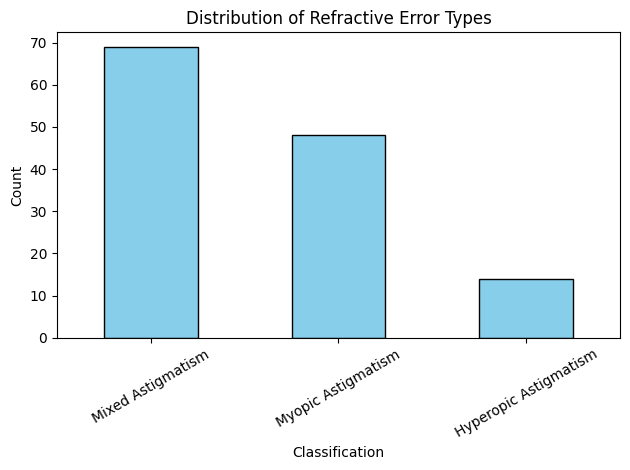

In [12]:
import matplotlib.pyplot as plt

day1AR['Classification'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Refractive Error Types')
plt.xlabel('Classification')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


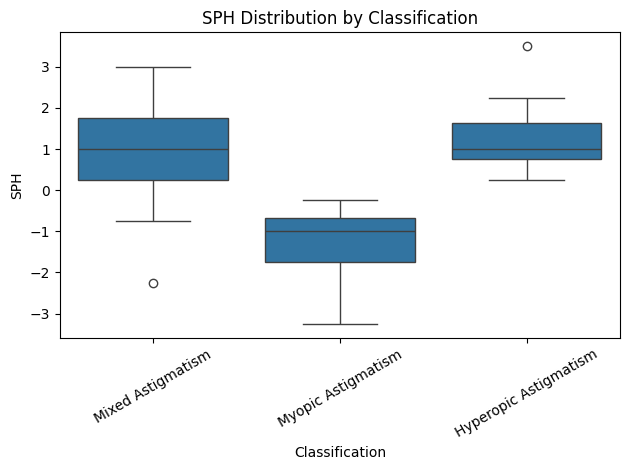

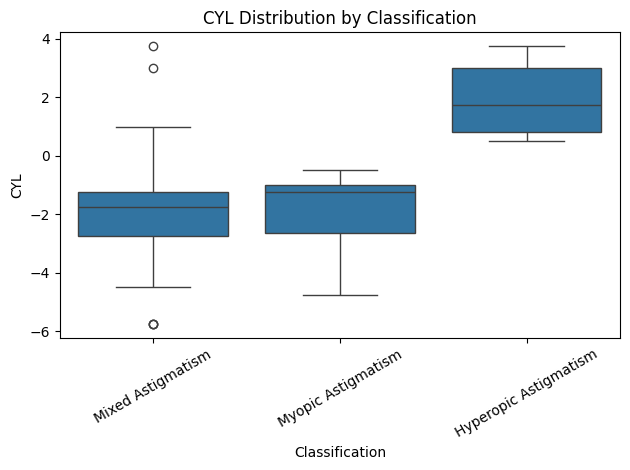

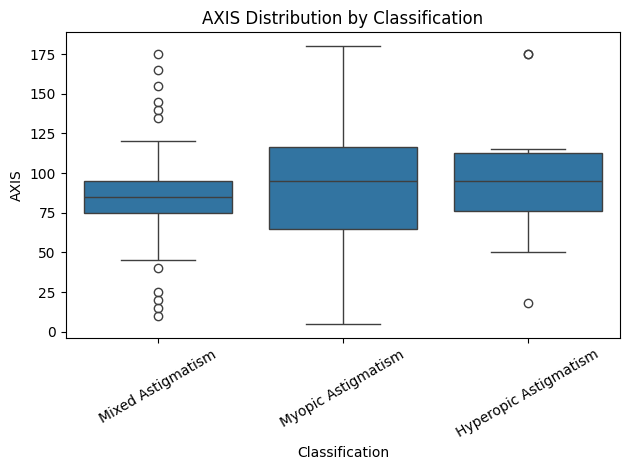

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# SPH boxplot
sns.boxplot(x='Classification', y='SPH', data=day1AR)
plt.title('SPH Distribution by Classification')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# CYL boxplot
sns.boxplot(x='Classification', y='CYL', data=day1AR)
plt.title('CYL Distribution by Classification')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# AXIS boxplot
sns.boxplot(x='Classification', y='AXIS', data=day1AR)
plt.title('AXIS Distribution by Classification')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [14]:
# Separate Myopic Astigmatism
myopic_df = day1AR[day1AR['Classification'] == 'Myopic Astigmatism']

# Separate Hyperopic Astigmatism
hyperopic_df = day1AR[day1AR['Classification'] == 'Hyperopic Astigmatism']

# Separate Mixed Astigmatism
mixed_df = day1AR[day1AR['Classification'] == 'Mixed Astigmatism']


In [15]:
myopic_df.shape, hyperopic_df.shape, mixed_df.shape

((48, 7), (14, 7), (69, 7))

In [16]:
myopic_df

,KH,KV,AX,SPH,CYL,AXIS,Classification
3,45.25,45.75,120,-0.75,-1.00,160.0,Myopic Astigmatism
7,43.00,44.50,90,-1,-0.50,100.0,Myopic Astigmatism
12,43.00,43.75,65,-1,-1.00,95.0,Myopic Astigmatism
17,44.75,45.25,80,-1.75,-1.25,15.0,Myopic Astigmatism
32,41.00,41.75,145,-0.5,-1.00,100.0,Myopic Astigmatism
37,43.25,44.00,125,-1.75,-3.75,80.0,Myopic Astigmatism
41,40.25,41.25,75,-1,-0.75,70.0,Myopic Astigmatism
42,44.00,44.25,140,-1.5,-1.00,50.0,Myopic Astigmatism
50,44.00,44.50,155,-0.75,-0.50,30.0,Myopic Astigmatism
52,45.00,45.25,175,-0.75,-1.25,75.0,Myopic Astigmatism


In [17]:
hyperopic_df

,KH,KV,AX,SPH,CYL,AXIS,Classification
4,45.50,47.00,80,0.25,2.00,75.0,Hyperopic Astigmatism
9,47.50,48.00,5,0.25,3.50,18.0,Hyperopic Astigmatism
19,43.75,45.00,85,2,3.00,105.0,Hyperopic Astigmatism
67,46.00,48.25,170,1,0.75,95.0,Hyperopic Astigmatism
76,44.50,44.75,55,1,0.50,95.0,Hyperopic Astigmatism
95,46.75,47.00,75,2.25,3.00,175.0,Hyperopic Astigmatism
110,44.00,45.50,90,1.75,2.25,100.0,Hyperopic Astigmatism
112,41.75,42.25,85,1.25,1.00,65.0,Hyperopic Astigmatism
113,45.25,46.00,90,1.25,0.75,115.0,Hyperopic Astigmatism
135,43.75,43.75,180,0.75,0.75,115.0,Hyperopic Astigmatism


In [18]:
mixed_df

,KH,KV,AX,SPH,CYL,AXIS,Classification
0,46.50,47.25,155,0.25,-1.50,115.0,Mixed Astigmatism
1,46.75,48.00,80,0.75,-2.25,80.0,Mixed Astigmatism
5,42.50,43.50,75,2,-2.00,90.0,Mixed Astigmatism
6,43.50,44.00,20,-0.5,3.75,75.0,Mixed Astigmatism
8,44.75,45.25,85,1.5,-3.25,45.0,Mixed Astigmatism
...,...,...,...,...,...,...,...
149,45.25,45.50,30,2.5,-1.00,65.0,Mixed Astigmatism
155,44.25,45.75,80,1.25,-1.00,80.0,Mixed Astigmatism
159,41.75,43.50,160,-2.25,3.00,50.0,Mixed Astigmatism
163,45.25,45.25,180,1.75,-4.25,95.0,Mixed Astigmatism


In [19]:
myopic_df.describe()

,KH,KV,AX,CYL,AXIS
count,48.000000,48.000000,48.00000,48.000000,48.000000
mean,44.473958,45.312500,105.93750,-1.848958,93.125000
std,1.896413,1.911958,49.05117,1.248126,43.924803
min,40.000000,41.250000,10.00000,-4.750000,5.000000
25%,43.250000,44.000000,68.75000,-2.625000,65.000000
50%,44.750000,45.250000,102.50000,-1.250000,95.000000
75%,46.000000,47.000000,151.25000,-1.000000,116.250000
max,48.500000,49.500000,180.00000,-0.500000,180.000000


In [20]:
myopic_df.drop('Classification', axis=1).corr()

,KH,KV,AX,SPH,CYL,AXIS
KH,1.000000,0.947042,0.036293,-0.113761,-0.056731,0.112745
KV,0.947042,1.000000,-0.008578,-0.087045,-0.110474,0.084079
AX,0.036293,-0.008578,1.000000,0.202318,0.372538,-0.190991
SPH,-0.113761,-0.087045,0.202318,1.000000,0.514843,0.159273
CYL,-0.056731,-0.110474,0.372538,0.514843,1.000000,-0.033534
AXIS,0.112745,0.084079,-0.190991,0.159273,-0.033534,1.000000


In [21]:
hyperopic_df.describe()

,KH,KV,AX,CYL,AXIS
count,14.000000,14.000000,14.000000,14.000000,14.000000
mean,44.625000,45.517857,89.642857,1.928571,97.000000
std,1.818045,1.993895,44.352794,1.178447,42.197339
min,41.500000,42.250000,5.000000,0.500000,18.000000
25%,43.750000,44.000000,76.250000,0.812500,76.250000
50%,44.625000,45.750000,85.000000,1.750000,95.000000
75%,45.875000,47.000000,90.000000,3.000000,112.500000
max,47.500000,48.250000,180.000000,3.750000,175.000000


In [22]:
hyperopic_df.drop('Classification', axis=1).corr()

,KH,KV,AX,SPH,CYL,AXIS
KH,1.000000,0.935679,-0.125804,0.253209,0.177276,0.212320
KV,0.935679,1.000000,-0.080381,0.194104,0.133580,0.085255
AX,-0.125804,-0.080381,1.000000,0.219173,-0.361098,0.475948
SPH,0.253209,0.194104,0.219173,1.000000,0.329701,0.778452
CYL,0.177276,0.133580,-0.361098,0.329701,1.000000,0.118338
AXIS,0.212320,0.085255,0.475948,0.778452,0.118338,1.000000


In [23]:
mixed_df.drop('Classification', axis=1).corr()

,KH,KV,AX,SPH,CYL,AXIS
KH,1.000000,0.941798,0.138236,0.056888,-0.189104,0.061283
KV,0.941798,1.000000,0.123346,0.040079,-0.148747,0.073609
AX,0.138236,0.123346,1.000000,-0.139823,-0.124202,0.130410
SPH,0.056888,0.040079,-0.139823,1.000000,-0.565898,-0.171078
CYL,-0.189104,-0.148747,-0.124202,-0.565898,1.000000,0.099833
AXIS,0.061283,0.073609,0.130410,-0.171078,0.099833,1.000000


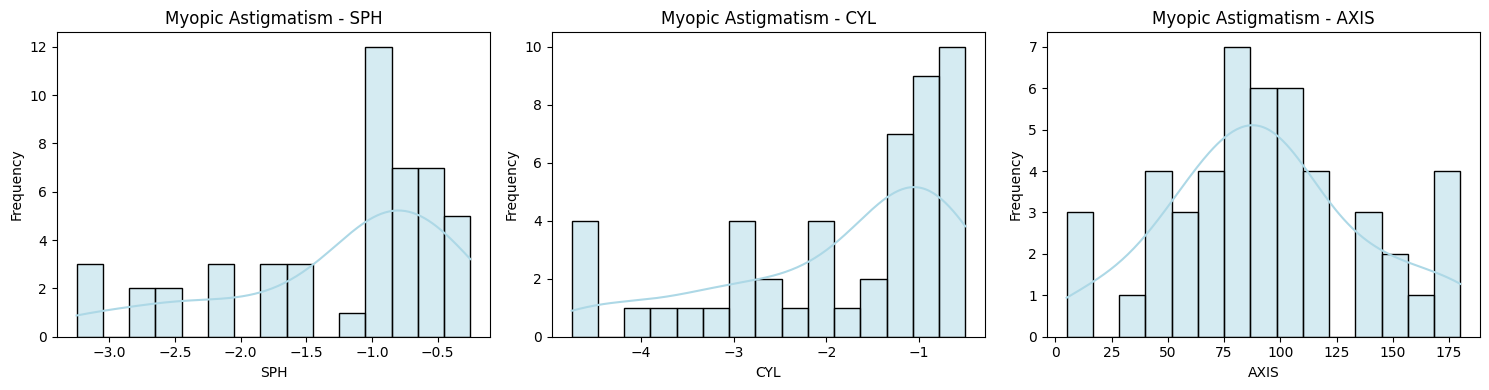

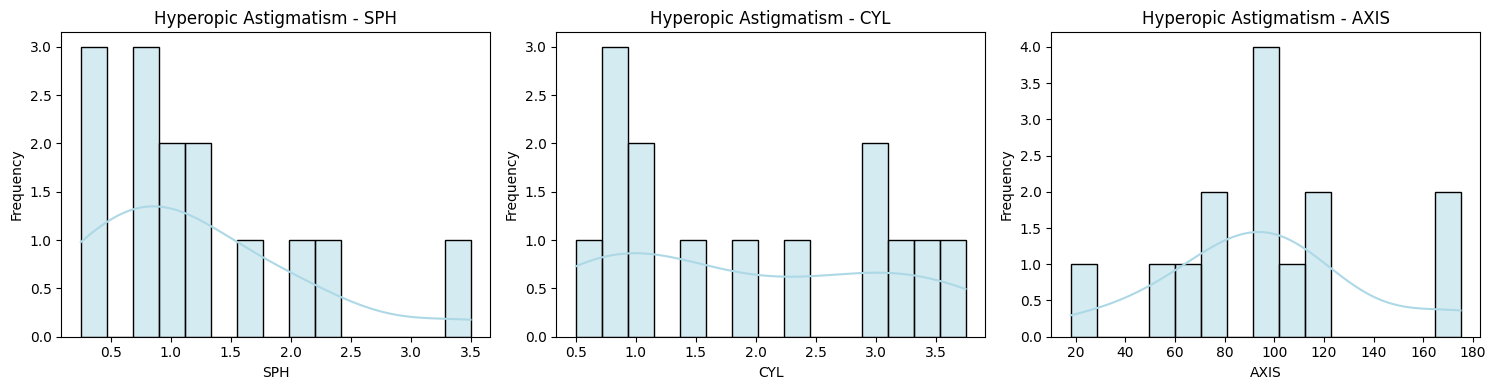

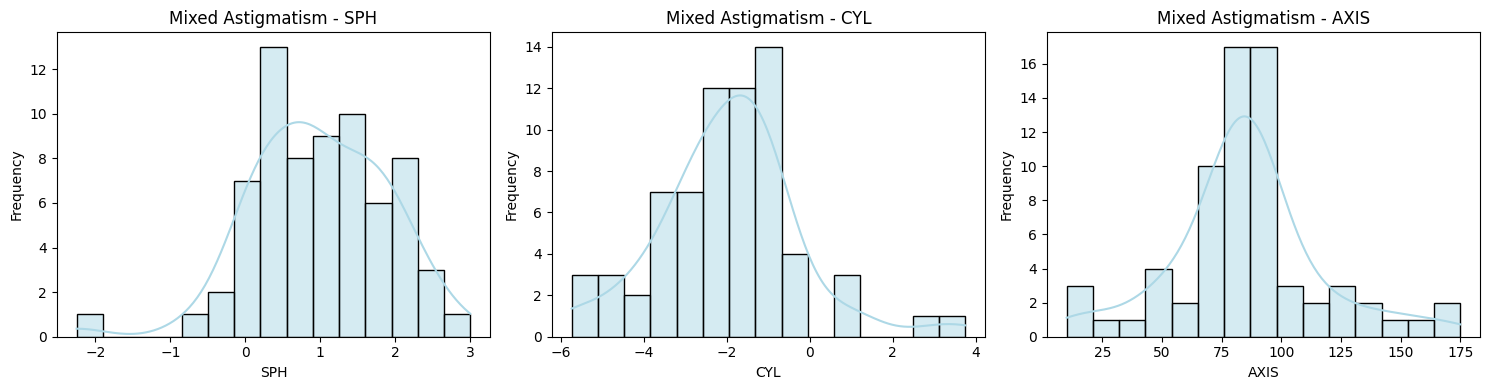

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_hist_with_kde(group_df, title_prefix):
    plt.figure(figsize=(15, 4))

    for i, col in enumerate(['SPH', 'CYL', 'AXIS']):
        plt.subplot(1, 3, i+1)
        sns.histplot(group_df[col].dropna(), kde=True, bins=15, color='lightblue', edgecolor='black')
        plt.title(f"{title_prefix} - {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

# Plot with bell curves for each group
plot_hist_with_kde(myopic_df, "Myopic Astigmatism")
plot_hist_with_kde(hyperopic_df, "Hyperopic Astigmatism")
plot_hist_with_kde(mixed_df, "Mixed Astigmatism")


/tmp/ipython-input-3783661550.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Classification', y='SPH', data=day1AR, palette='pastel')


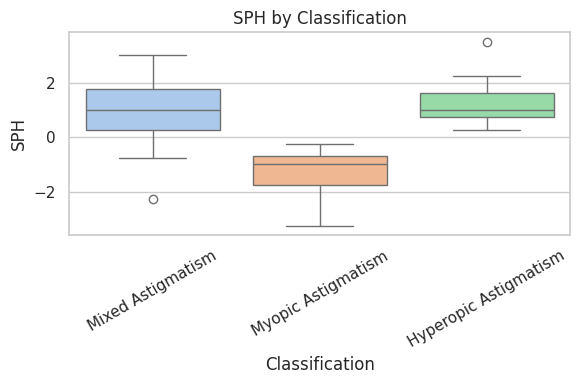

/tmp/ipython-input-3783661550.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Classification', y='CYL', data=day1AR, palette='pastel')


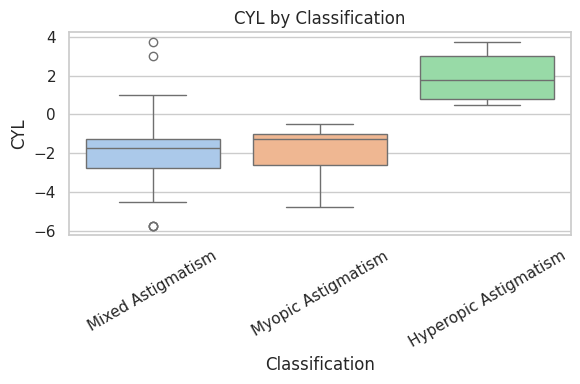

/tmp/ipython-input-3783661550.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Classification', y='AXIS', data=day1AR, palette='pastel')


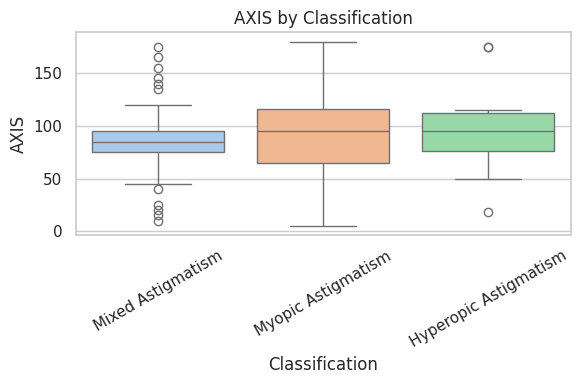

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set(style="whitegrid")

# Boxplot for SPH
plt.figure(figsize=(6, 4))
sns.boxplot(x='Classification', y='SPH', data=day1AR, palette='pastel')
plt.title('SPH by Classification')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Boxplot for CYL
plt.figure(figsize=(6, 4))
sns.boxplot(x='Classification', y='CYL', data=day1AR, palette='pastel')
plt.title('CYL by Classification')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Boxplot for AXIS
plt.figure(figsize=(6, 4))
sns.boxplot(x='Classification', y='AXIS', data=day1AR, palette='pastel')
plt.title('AXIS by Classification')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [26]:
day1AR['preopcyl'] = day1AR['KV']-day1AR['KH']
day1AR

,KH,KV,AX,SPH,CYL,AXIS,Classification,preopcyl
0,46.50,47.25,155,0.25,-1.50,115.0,Mixed Astigmatism,0.75
1,46.75,48.00,80,0.75,-2.25,80.0,Mixed Astigmatism,1.25
3,45.25,45.75,120,-0.75,-1.00,160.0,Myopic Astigmatism,0.50
4,45.50,47.00,80,0.25,2.00,75.0,Hyperopic Astigmatism,1.50
5,42.50,43.50,75,2,-2.00,90.0,Mixed Astigmatism,1.00
...,...,...,...,...,...,...,...,...
165,43.25,44.00,60,-2.75,-3.00,60.0,Myopic Astigmatism,0.75
167,47.00,48.25,165,1.25,-1.75,15.0,Mixed Astigmatism,1.25
168,42.00,42.50,110,-0.75,-1.25,95.0,Myopic Astigmatism,0.50
169,45.00,46.25,165,-2.75,-3.00,75.0,Myopic Astigmatism,1.25


In [27]:
myopic_df['preopcyl'] = myopic_df['KV']-myopic_df['KH']
myopic_df

/tmp/ipython-input-1664374083.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  myopic_df['preopcyl'] = myopic_df['KV']-myopic_df['KH']


,KH,KV,AX,SPH,CYL,AXIS,Classification,preopcyl
3,45.25,45.75,120,-0.75,-1.00,160.0,Myopic Astigmatism,0.50
7,43.00,44.50,90,-1,-0.50,100.0,Myopic Astigmatism,1.50
12,43.00,43.75,65,-1,-1.00,95.0,Myopic Astigmatism,0.75
17,44.75,45.25,80,-1.75,-1.25,15.0,Myopic Astigmatism,0.50
32,41.00,41.75,145,-0.5,-1.00,100.0,Myopic Astigmatism,0.75
37,43.25,44.00,125,-1.75,-3.75,80.0,Myopic Astigmatism,0.75
41,40.25,41.25,75,-1,-0.75,70.0,Myopic Astigmatism,1.00
42,44.00,44.25,140,-1.5,-1.00,50.0,Myopic Astigmatism,0.25
50,44.00,44.50,155,-0.75,-0.50,30.0,Myopic Astigmatism,0.50
52,45.00,45.25,175,-0.75,-1.25,75.0,Myopic Astigmatism,0.25


In [28]:
hyperopic_df['preopcyl'] = hyperopic_df['KV']-hyperopic_df['KH']
hyperopic_df


/tmp/ipython-input-970133251.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hyperopic_df['preopcyl'] = hyperopic_df['KV']-hyperopic_df['KH']


,KH,KV,AX,SPH,CYL,AXIS,Classification,preopcyl
4,45.50,47.00,80,0.25,2.00,75.0,Hyperopic Astigmatism,1.50
9,47.50,48.00,5,0.25,3.50,18.0,Hyperopic Astigmatism,0.50
19,43.75,45.00,85,2,3.00,105.0,Hyperopic Astigmatism,1.25
67,46.00,48.25,170,1,0.75,95.0,Hyperopic Astigmatism,2.25
76,44.50,44.75,55,1,0.50,95.0,Hyperopic Astigmatism,0.25
95,46.75,47.00,75,2.25,3.00,175.0,Hyperopic Astigmatism,0.25
110,44.00,45.50,90,1.75,2.25,100.0,Hyperopic Astigmatism,1.50
112,41.75,42.25,85,1.25,1.00,65.0,Hyperopic Astigmatism,0.50
113,45.25,46.00,90,1.25,0.75,115.0,Hyperopic Astigmatism,0.75
135,43.75,43.75,180,0.75,0.75,115.0,Hyperopic Astigmatism,0.00


In [29]:
mixed_df['preopcyl'] = mixed_df['KV']-mixed_df['KH']
mixed_df


/tmp/ipython-input-3961326065.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mixed_df['preopcyl'] = mixed_df['KV']-mixed_df['KH']


,KH,KV,AX,SPH,CYL,AXIS,Classification,preopcyl
0,46.50,47.25,155,0.25,-1.50,115.0,Mixed Astigmatism,0.75
1,46.75,48.00,80,0.75,-2.25,80.0,Mixed Astigmatism,1.25
5,42.50,43.50,75,2,-2.00,90.0,Mixed Astigmatism,1.00
6,43.50,44.00,20,-0.5,3.75,75.0,Mixed Astigmatism,0.50
8,44.75,45.25,85,1.5,-3.25,45.0,Mixed Astigmatism,0.50
...,...,...,...,...,...,...,...,...
149,45.25,45.50,30,2.5,-1.00,65.0,Mixed Astigmatism,0.25
155,44.25,45.75,80,1.25,-1.00,80.0,Mixed Astigmatism,1.50
159,41.75,43.50,160,-2.25,3.00,50.0,Mixed Astigmatism,1.75
163,45.25,45.25,180,1.75,-4.25,95.0,Mixed Astigmatism,0.00


In [30]:
myopic_df

,KH,KV,AX,SPH,CYL,AXIS,Classification,preopcyl
3,45.25,45.75,120,-0.75,-1.00,160.0,Myopic Astigmatism,0.50
7,43.00,44.50,90,-1,-0.50,100.0,Myopic Astigmatism,1.50
12,43.00,43.75,65,-1,-1.00,95.0,Myopic Astigmatism,0.75
17,44.75,45.25,80,-1.75,-1.25,15.0,Myopic Astigmatism,0.50
32,41.00,41.75,145,-0.5,-1.00,100.0,Myopic Astigmatism,0.75
37,43.25,44.00,125,-1.75,-3.75,80.0,Myopic Astigmatism,0.75
41,40.25,41.25,75,-1,-0.75,70.0,Myopic Astigmatism,1.00
42,44.00,44.25,140,-1.5,-1.00,50.0,Myopic Astigmatism,0.25
50,44.00,44.50,155,-0.75,-0.50,30.0,Myopic Astigmatism,0.50
52,45.00,45.25,175,-0.75,-1.25,75.0,Myopic Astigmatism,0.25


In [31]:
# Convert axes to double-angle in radians
myopic_df['preopcyl']=myopic_df['KV']-myopic_df['KH']
myopic_df['postopcyl'] = myopic_df['CYL']

myopic_df['pre_theta'] = np.deg2rad(myopic_df['AX'] * 2)
myopic_df['post_theta'] = np.deg2rad(myopic_df['AXIS'] * 2)

# Convert to X, Y (Cartesian)
myopic_df['pre_x'] = myopic_df['preopcyl'] * np.cos(myopic_df['pre_theta'])
myopic_df['pre_y'] = myopic_df['preopcyl'] * np.sin(myopic_df['pre_theta'])

myopic_df['post_x'] = myopic_df['CYL'] * np.cos(myopic_df['post_theta'])
myopic_df['post_y'] = myopic_df['CYL'] * np.sin(myopic_df['post_theta'])

# SIA vector = post - pre
myopic_df['sia_x'] = myopic_df['post_x'] - myopic_df['pre_x']
myopic_df['sia_y'] = myopic_df['post_y'] - myopic_df['pre_y']

# SIA magnitude and axis
myopic_df['SIA_magnitude'] = np.sqrt(myopic_df['sia_x']**2 + myopic_df['sia_y']**2)
myopic_df['SIA_axis'] = (np.rad2deg(np.arctan2(myopic_df['sia_y'], myopic_df['sia_x'])) / 2) % 180

# Round for cleaner display
myopic_df['SIA_magnitude'] = myopic_df['SIA_magnitude'].round(2)
myopic_df['SIA_axis'] = myopic_df['SIA_axis'].round(1)

# Show the final result
print(myopic_df[['SIA_magnitude', 'SIA_axis']])


     SIA_magnitude  SIA_axis
3             1.19      57.8
7             1.98       2.5
12            1.52     172.4
17            1.00     116.2
32            1.25      28.4
37            3.82     175.7
41            1.74     162.9
42            0.75     140.0
50            0.57      92.5
52            1.02     162.6
55            3.72       1.3
56            2.48      18.7
66            0.45      64.5
70            2.60      79.2
71            1.65      18.5
72            0.33     139.3
75            1.45      19.9
79            1.65      58.5
80            0.17     122.5
82            2.74      25.9
84            2.06      43.0
88            0.94      97.2
96            3.13       0.5
106           2.07     109.2
108           0.39     102.5
114           2.90     158.8
115           5.41       8.0
116           3.06     154.2
117           0.66      80.4
118           1.23     149.0
121           4.99     169.0
122           2.05     177.5
123           3.97     164.6
127           

/tmp/ipython-input-1811692269.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  myopic_df['preopcyl']=myopic_df['KV']-myopic_df['KH']
/tmp/ipython-input-1811692269.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  myopic_df['postopcyl'] = myopic_df['CYL']
/tmp/ipython-input-1811692269.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pan

In [32]:
import numpy as np

def to_cartesian(cyl, axis_deg):
    # Convert cylinder vector to X, Y components
    angle_rad = np.deg2rad(2 * axis_deg)  # double angle for astigmatism
    x = cyl * np.cos(angle_rad)
    y = cyl * np.sin(angle_rad)
    return x, y

def from_cartesian(x, y):
    # Convert X, Y to cylinder and axis
    cyl = np.hypot(x, y)  # magnitude
    axis = np.rad2deg(np.arctan2(y, x)) / 2  # halve angle back
    if axis < 0:
        axis += 180  # normalize between 0-180
    return cyl, axis

def calculate_sia(pre_cyl, pre_axis, post_cyl, post_axis):
    # Convert pre- and post-op to Cartesian
    x_pre, y_pre = to_cartesian(pre_cyl, pre_axis)
    x_post, y_post = to_cartesian(post_cyl, post_axis)

    # SIA vector = post - pre
    x_sia = x_post - x_pre
    y_sia = y_post - y_pre

    # SIA magnitude and axis
    sia_mag, sia_axis = from_cartesian(x_sia, y_sia)

    print(f"Pre-op vector (X, Y): ({x_pre:.2f}, {y_pre:.2f})")
    print(f"Post-op vector (X, Y): ({x_post:.2f}, {y_post:.2f})")
    print(f"SIA vector (X, Y): ({x_sia:.2f}, {y_sia:.2f})")
    print(f"SIA Magnitude: {sia_mag:.2f} D")
    print(f"SIA Axis: {sia_axis:.2f}°")

# Example input (in diopters and degrees)
pre_cyl = 0.50
pre_axis = 120
post_cyl = -1.00
post_axis = 160

calculate_sia(pre_cyl, pre_axis, post_cyl, post_axis)


Pre-op vector (X, Y): (-0.25, -0.43)
Post-op vector (X, Y): (-0.77, 0.64)
SIA vector (X, Y): (-0.52, 1.08)
SIA Magnitude: 1.19 D
SIA Axis: 57.81°


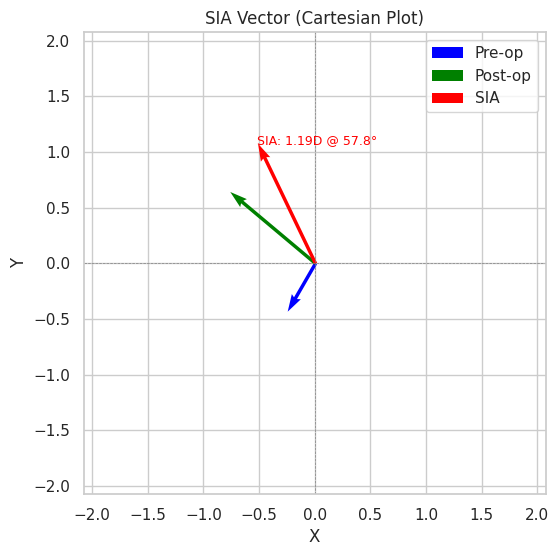

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Function to convert cylinder and axis to X, Y components
def to_cartesian(cyl, axis_deg):
    angle_rad = np.deg2rad(2 * axis_deg)  # double angle
    x = cyl * np.cos(angle_rad)
    y = cyl * np.sin(angle_rad)
    return x, y

# Function to convert X, Y back to magnitude and axis
def from_cartesian(x, y):
    cyl = np.hypot(x, y)
    axis = np.rad2deg(np.arctan2(y, x)) / 2
    if axis < 0:
        axis += 180
    return cyl, axis

# Main function
def plot_sia_vector(pre_cyl, pre_axis, post_cyl, post_axis):
    # Convert to Cartesian
    x_pre, y_pre = to_cartesian(pre_cyl, pre_axis)
    x_post, y_post = to_cartesian(post_cyl, post_axis)

    # SIA = post - pre
    x_sia = x_post - x_pre
    y_sia = y_post - y_pre
    sia_mag, sia_axis = from_cartesian(x_sia, y_sia)

    # Plot setup
    plt.figure(figsize=(6, 6))
    ax = plt.gca()
    ax.set_aspect('equal')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.5)

    # Plot vectors from origin
    plt.quiver(0, 0, x_pre, y_pre, angles='xy', scale_units='xy', scale=1, color='blue', label='Pre-op')
    plt.quiver(0, 0, x_post, y_post, angles='xy', scale_units='xy', scale=1, color='green', label='Post-op')
    plt.quiver(0, 0, x_sia, y_sia, angles='xy', scale_units='xy', scale=1, color='red', label='SIA')

    # Annotate
    plt.text(x_sia, y_sia, f'SIA: {sia_mag:.2f}D @ {sia_axis:.1f}°', color='red', fontsize=9)

    # Axes limits
    max_val = max(abs(x_pre), abs(y_pre), abs(x_post), abs(y_post), abs(x_sia), abs(y_sia)) + 1
    plt.xlim(-max_val, max_val)
    plt.ylim(-max_val, max_val)

    plt.title("SIA Vector (Cartesian Plot)")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.grid(True)
    plt.show()

# Sample input
pre_cyl = 0.50
pre_axis = 120
post_cyl = -1.00
post_axis = 160

plot_sia_vector(pre_cyl, pre_axis, post_cyl, post_axis)


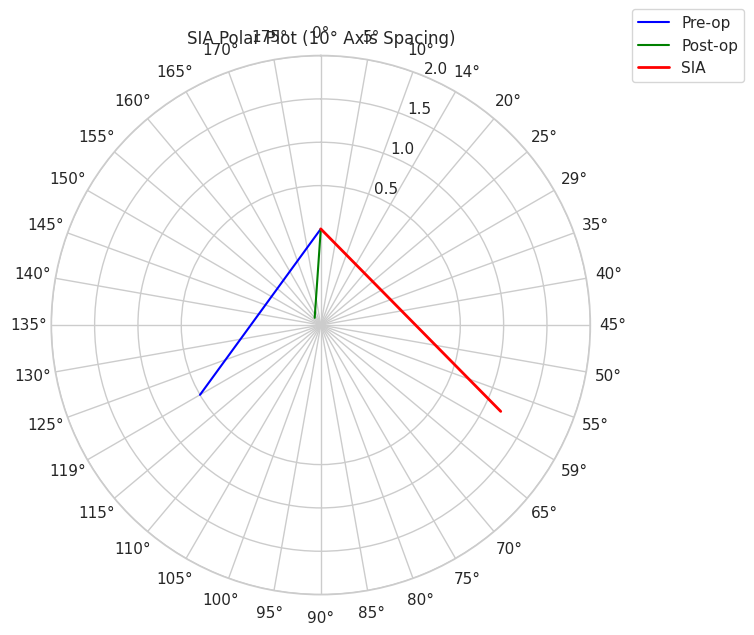

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Convert cylinder and axis to polar (double angle)
def to_polar(cyl, axis_deg):
    theta_rad = np.deg2rad(2 * axis_deg)
    r = cyl
    return theta_rad, r

# Compute SIA vector from pre- and post-op astigmatism
def compute_sia(pre_cyl, pre_axis, post_cyl, post_axis):
    x_pre = pre_cyl * np.cos(np.deg2rad(2 * pre_axis))
    y_pre = pre_cyl * np.sin(np.deg2rad(2 * pre_axis))
    x_post = post_cyl * np.cos(np.deg2rad(2 * post_axis))
    y_post = post_cyl * np.sin(np.deg2rad(2 * post_axis))

    x_sia = x_post - x_pre
    y_sia = y_post - y_pre

    r_sia = np.hypot(x_sia, y_sia)
    theta_sia = np.rad2deg(np.arctan2(y_sia, x_sia)) / 2
    if theta_sia < 0:
        theta_sia += 180
    return r_sia, np.deg2rad(2 * theta_sia)

# Polar plot with 10° spacing
def plot_polar_sia(pre_cyl, pre_axis, post_cyl, post_axis):
    theta_pre, r_pre = to_polar(pre_cyl, pre_axis)
    theta_post, r_post = to_polar(post_cyl, post_axis)
    r_sia, theta_sia = compute_sia(pre_cyl, pre_axis, post_cyl, post_axis)

    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, polar=True)
    ax.set_theta_zero_location("N")  # 0° at top
    ax.set_theta_direction(-1)       # Clockwise

    # Plot vectors
    ax.plot([0, theta_pre], [0, r_pre], label='Pre-op', color='blue')
    ax.plot([0, theta_post], [0, r_post], label='Post-op', color='green')
    ax.plot([0, theta_sia], [0, r_sia], label='SIA', color='red', linewidth=2)

    # 10-degree spacing for angular ticks (every 10°, from 0° to 350°)
    angles = np.deg2rad(np.arange(0, 360, 10))
    angle_labels = [f"{int(np.rad2deg(a)/2)%180}°" for a in angles]  # halve back and wrap to 0–180°
    ax.set_xticks(angles)
    ax.set_xticklabels(angle_labels)

    # Radial ticks (adjust as needed)
    ax.set_rticks([0.5, 1.0, 1.5, 2.0])

    ax.set_title("SIA Polar Plot (10° Axis Spacing)", va='bottom')
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()

# Example
pre_cyl = 0.50
pre_axis = 120
post_cyl = -1.00
post_axis = 160

plot_polar_sia(pre_cyl, pre_axis, post_cyl, post_axis)


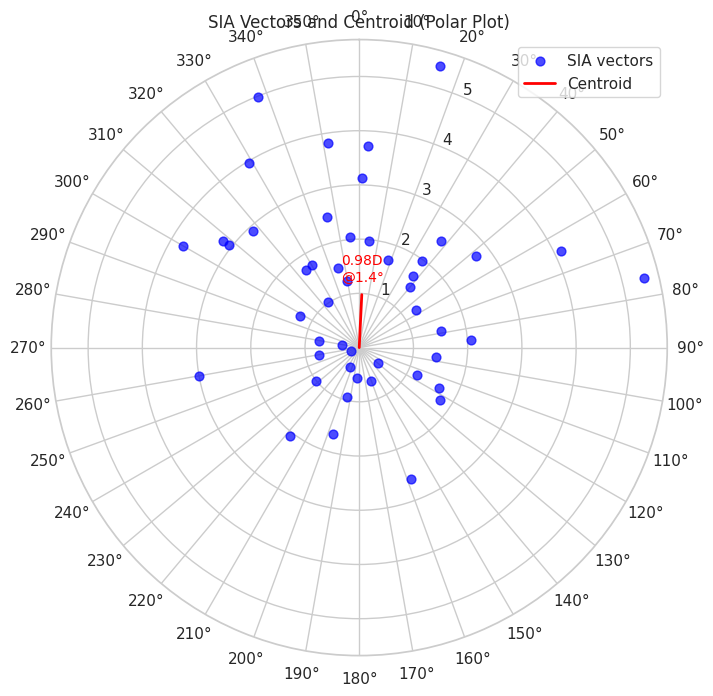

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure required columns exist
required_cols = ['sia_x', 'sia_y', 'SIA_magnitude', 'SIA_axis']
missing_cols = [col for col in required_cols if col not in myopic_df.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

# --- Compute centroid ---
centroid_x = myopic_df['sia_x'].mean()
centroid_y = myopic_df['sia_y'].mean()
centroid_mag = np.sqrt(centroid_x**2 + centroid_y**2)
centroid_axis = (np.rad2deg(np.arctan2(centroid_y, centroid_x)) / 2) % 180
centroid_theta = np.deg2rad(centroid_axis * 2)

# --- Convert data points to polar ---
theta = np.deg2rad(myopic_df['SIA_axis'] * 2)  # double-angle domain
r = myopic_df['SIA_magnitude']

# --- Plot ---
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, polar=True)
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_thetagrids(np.arange(0, 360, 10))  # 10° spacing

# Plot SIA data points
ax.scatter(theta, r, color='blue', s=40, alpha=0.7, label='SIA vectors')

# Plot centroid vector
ax.plot([0, centroid_theta], [0, centroid_mag], color='red', linewidth=2, label='Centroid')

# Label the centroid
ax.text(centroid_theta, centroid_mag + 0.2,
        f"{centroid_mag:.2f}D\n@{centroid_axis:.1f}°",
        ha='center', va='bottom', fontsize=10, color='red')

# Final formatting
ax.set_title("SIA Vectors and Centroid (Polar Plot)", va='bottom')
ax.legend(loc='upper right')
ax.grid(True)
plt.show()


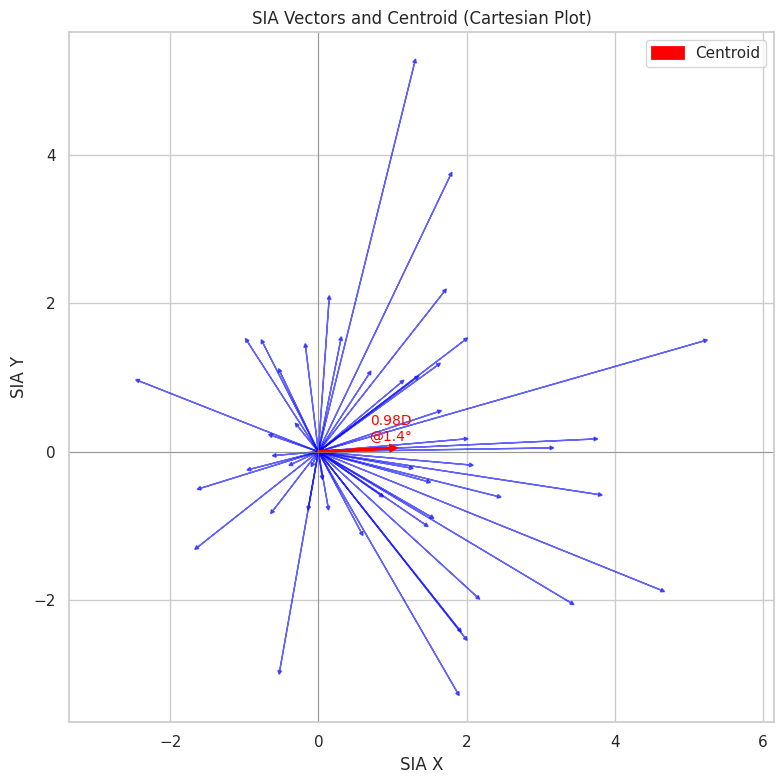

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure required columns
required_cols = ['sia_x', 'sia_y']
missing_cols = [col for col in required_cols if col not in myopic_df.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

# --- Compute centroid ---
centroid_x = myopic_df['sia_x'].mean()
centroid_y = myopic_df['sia_y'].mean()

# --- Plot setup ---
plt.figure(figsize=(8, 8))
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)

# Plot all SIA vectors
for i, row in myopic_df.iterrows():
    plt.arrow(0, 0, row['sia_x'], row['sia_y'],
              head_width=0.05, head_length=0.05,
              fc='blue', ec='blue', alpha=0.6)

# Plot centroid vector
plt.arrow(0, 0, centroid_x, centroid_y,
          head_width=0.07, head_length=0.07,
          fc='red', ec='red', lw=2, label='Centroid')

# Add centroid label at the tip
plt.text(centroid_x, centroid_y + 0.1,
         f"{np.sqrt(centroid_x**2 + centroid_y**2):.2f}D\n@{(np.rad2deg(np.arctan2(centroid_y, centroid_x))/2)%180:.1f}°",
         fontsize=10, color='red', ha='center')

# Formatting
plt.xlabel("SIA X")
plt.ylabel("SIA Y")
plt.title("SIA Vectors and Centroid (Cartesian Plot)")
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [37]:
myopic_df['SIA_magnitude'].describe(), myopic_df['SIA_axis'].describe()

(count    48.000000
 mean      2.098333
 std       1.319086
 min       0.170000
 25%       1.220000
 50%       1.745000
 75%       2.925000
 max       5.410000
 Name: SIA_magnitude, dtype: float64,
 count     48.000000
 mean      93.658333
 std       61.033628
 min        0.500000
 25%       36.625000
 50%       97.900000
 75%      154.125000
 max      177.500000
 Name: SIA_axis, dtype: float64)

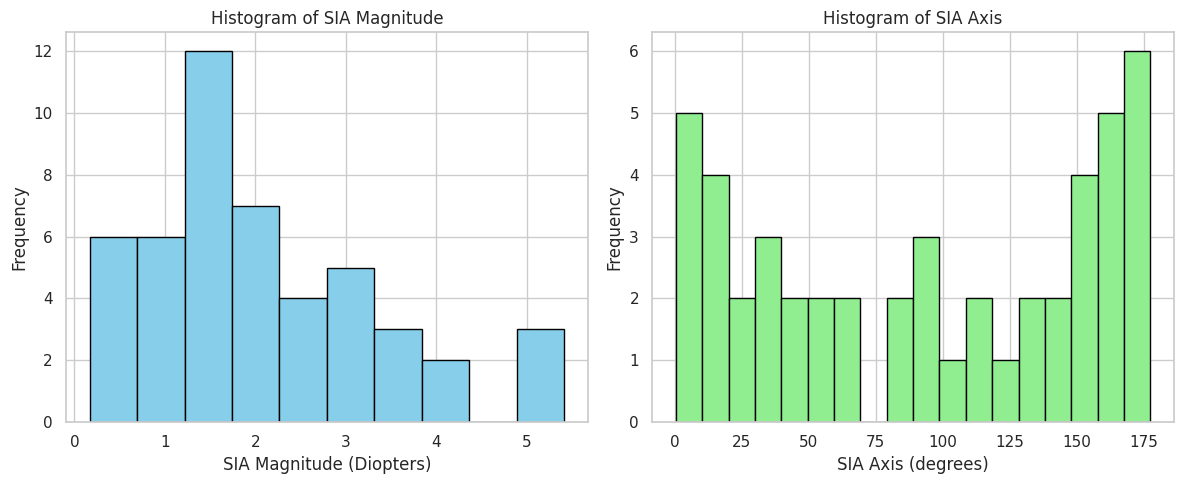

In [38]:
import matplotlib.pyplot as plt

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram for SIA Magnitude
axes[0].hist(myopic_df['SIA_magnitude'], bins=10, color='skyblue', edgecolor='black')
axes[0].set_title('Histogram of SIA Magnitude')
axes[0].set_xlabel('SIA Magnitude (Diopters)')
axes[0].set_ylabel('Frequency')
axes[0].grid(True)

# Histogram for SIA Axis
axes[1].hist(myopic_df['SIA_axis'], bins=18, color='lightgreen', edgecolor='black')
axes[1].set_title('Histogram of SIA Axis')
axes[1].set_xlabel('SIA Axis (degrees)')
axes[1].set_ylabel('Frequency')
axes[1].grid(True)

plt.tight_layout()
plt.show()


/tmp/ipython-input-2804979709.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, patch_artist=True,


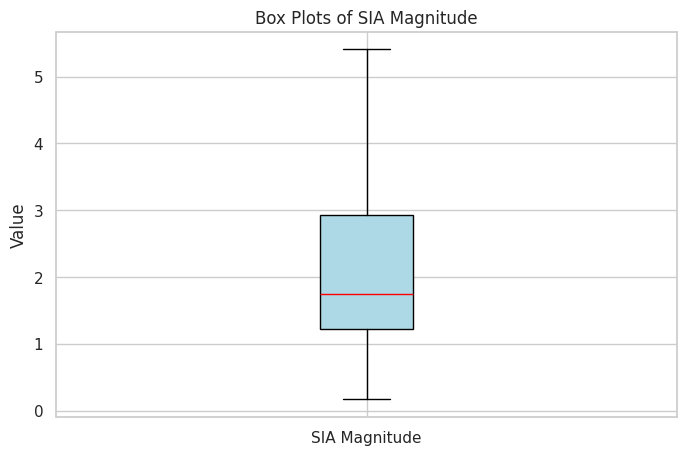

In [39]:
import matplotlib.pyplot as plt

# Extract the two columns
data = [myopic_df['SIA_magnitude'].dropna()]

# Create the box plots side by side
plt.figure(figsize=(8, 5))
plt.boxplot(data, patch_artist=True,
            labels=['SIA Magnitude'],
            boxprops=dict(facecolor='lightblue'),
            medianprops=dict(color='red'))

plt.title('Box Plots of SIA Magnitude')
plt.ylabel('Value')
plt.grid(True)
plt.show()


/tmp/ipython-input-566898634.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, patch_artist=True,


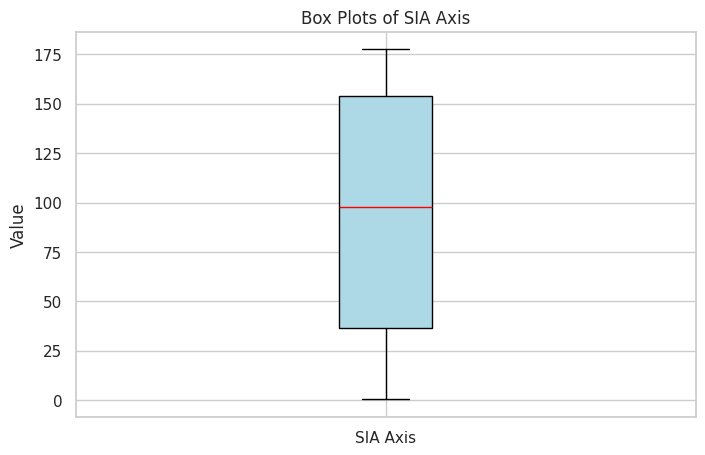

In [40]:
import matplotlib.pyplot as plt

# Extract the two columns
data = [myopic_df['SIA_axis'].dropna()]

# Create the box plots side by side
plt.figure(figsize=(8, 5))
plt.boxplot(data, patch_artist=True,
            labels=['SIA Axis'],
            boxprops=dict(facecolor='lightblue'),
            medianprops=dict(color='red'))

plt.title('Box Plots of SIA Axis')
plt.ylabel('Value')
plt.grid(True)
plt.show()


## Hyperopic atigmatism

In [41]:
hyperopic_df

,KH,KV,AX,SPH,CYL,AXIS,Classification,preopcyl
4,45.50,47.00,80,0.25,2.00,75.0,Hyperopic Astigmatism,1.50
9,47.50,48.00,5,0.25,3.50,18.0,Hyperopic Astigmatism,0.50
19,43.75,45.00,85,2,3.00,105.0,Hyperopic Astigmatism,1.25
67,46.00,48.25,170,1,0.75,95.0,Hyperopic Astigmatism,2.25
76,44.50,44.75,55,1,0.50,95.0,Hyperopic Astigmatism,0.25
95,46.75,47.00,75,2.25,3.00,175.0,Hyperopic Astigmatism,0.25
110,44.00,45.50,90,1.75,2.25,100.0,Hyperopic Astigmatism,1.50
112,41.75,42.25,85,1.25,1.00,65.0,Hyperopic Astigmatism,0.50
113,45.25,46.00,90,1.25,0.75,115.0,Hyperopic Astigmatism,0.75
135,43.75,43.75,180,0.75,0.75,115.0,Hyperopic Astigmatism,0.00


In [42]:
import numpy as np

# Calculate preoperative cylinder as KV - KH
hyperopic_df['preopcyl'] = hyperopic_df['KV'] - hyperopic_df['KH']
hyperopic_df['postopcyl'] = hyperopic_df['CYL']

# Convert axes to double-angle in radians
hyperopic_df['pre_theta'] = np.deg2rad(hyperopic_df['AX'] * 2)
hyperopic_df['post_theta'] = np.deg2rad(hyperopic_df['AXIS'] * 2)

# Convert to X, Y (Cartesian)
hyperopic_df['pre_x'] = hyperopic_df['preopcyl'] * np.cos(hyperopic_df['pre_theta'])
hyperopic_df['pre_y'] = hyperopic_df['preopcyl'] * np.sin(hyperopic_df['pre_theta'])

hyperopic_df['post_x'] = hyperopic_df['postopcyl'] * np.cos(hyperopic_df['post_theta'])
hyperopic_df['post_y'] = hyperopic_df['postopcyl'] * np.sin(hyperopic_df['post_theta'])

# SIA vector = post - pre
hyperopic_df['sia_x'] = hyperopic_df['post_x'] - hyperopic_df['pre_x']
hyperopic_df['sia_y'] = hyperopic_df['post_y'] - hyperopic_df['pre_y']

# SIA magnitude and axis
hyperopic_df['SIA_magnitude'] = np.sqrt(hyperopic_df['sia_x']**2 + hyperopic_df['sia_y']**2)
hyperopic_df['SIA_axis'] = (np.rad2deg(np.arctan2(hyperopic_df['sia_y'], hyperopic_df['sia_x'])) / 2) % 180

# Round for clean display
hyperopic_df['SIA_magnitude'] = hyperopic_df['SIA_magnitude'].round(2)
hyperopic_df['SIA_axis'] = hyperopic_df['SIA_axis'].round(1)

# Show the final result
print(hyperopic_df[['SIA_magnitude', 'SIA_axis']])


     SIA_magnitude  SIA_axis
4             0.58      61.8
9             3.06      20.1
19            2.19     115.7
67            2.92      83.7
76            0.52     109.2
95            3.24     174.2
110           0.98     115.7
112           0.70      51.2
113           0.63     147.5
135           0.75     115.0
136           2.75      80.0
148           3.45     178.9
154           1.27      96.9
164           1.03     149.9


/tmp/ipython-input-2152525650.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hyperopic_df['preopcyl'] = hyperopic_df['KV'] - hyperopic_df['KH']
/tmp/ipython-input-2152525650.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hyperopic_df['postopcyl'] = hyperopic_df['CYL']
/tmp/ipython-input-2152525650.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pa

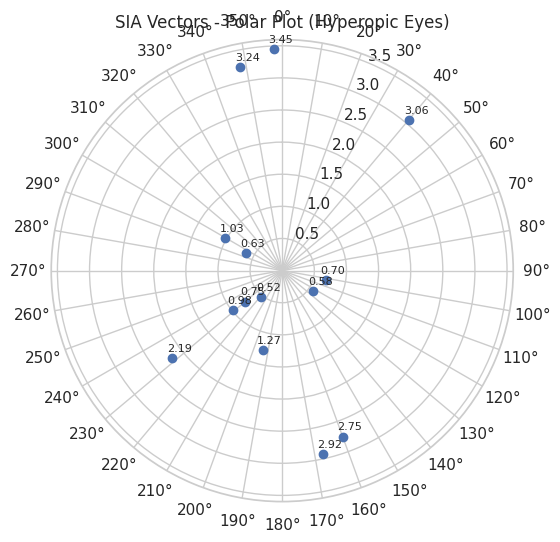

In [43]:
import matplotlib.pyplot as plt

# Create a polar plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, polar=True)

# Convert SIA axis to radians and double the angle for plotting
theta = np.deg2rad(hyperopic_df['SIA_axis'] * 2)
r = hyperopic_df['SIA_magnitude']

# Plot each vector from origin
ax.plot(theta, r, 'o', label='SIA Vectors')
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_thetagrids(range(0, 360, 10))

# Annotate with magnitude values
for i in range(len(hyperopic_df)):
    ax.annotate(f"{r.iloc[i]:.2f}",
                (theta.iloc[i], r.iloc[i]),
                textcoords="offset points", xytext=(5, 5), ha='center', fontsize=8)

# Title and show
ax.set_title('SIA Vectors - Polar Plot (Hyperopic Eyes)', va='bottom')
plt.show()


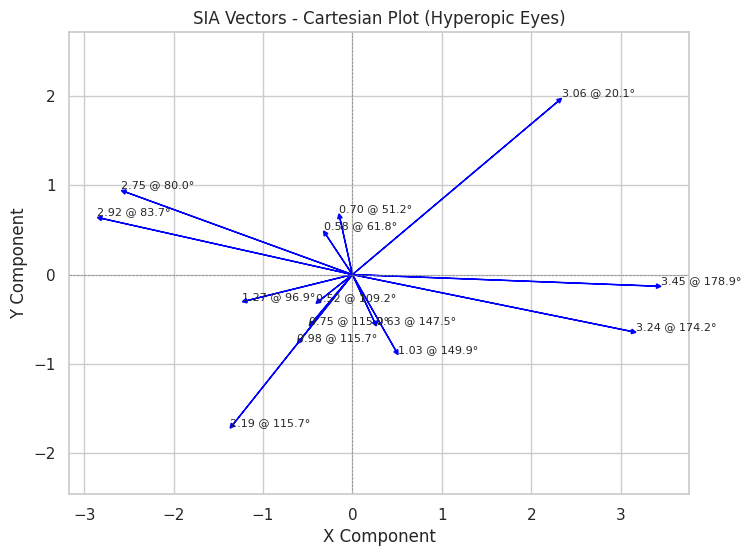

In [44]:
import matplotlib.pyplot as plt

# Create Cartesian plot
plt.figure(figsize=(8, 6))
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)

# Plot SIA vectors from origin to (sia_x, sia_y)
for i in range(len(hyperopic_df)):
    x = hyperopic_df['sia_x'].iloc[i]
    y = hyperopic_df['sia_y'].iloc[i]
    plt.arrow(0, 0, x, y, head_width=0.05, head_length=0.05, fc='blue', ec='blue', length_includes_head=True)
    plt.text(x, y, f"{hyperopic_df['SIA_magnitude'].iloc[i]:.2f} @ {hyperopic_df['SIA_axis'].iloc[i]:.1f}°",
             fontsize=8, ha='left', va='bottom')

# Axis labels and title
plt.xlabel('X Component')
plt.ylabel('Y Component')
plt.title('SIA Vectors - Cartesian Plot (Hyperopic Eyes)')
plt.grid(True)
plt.axis('equal')
plt.show()


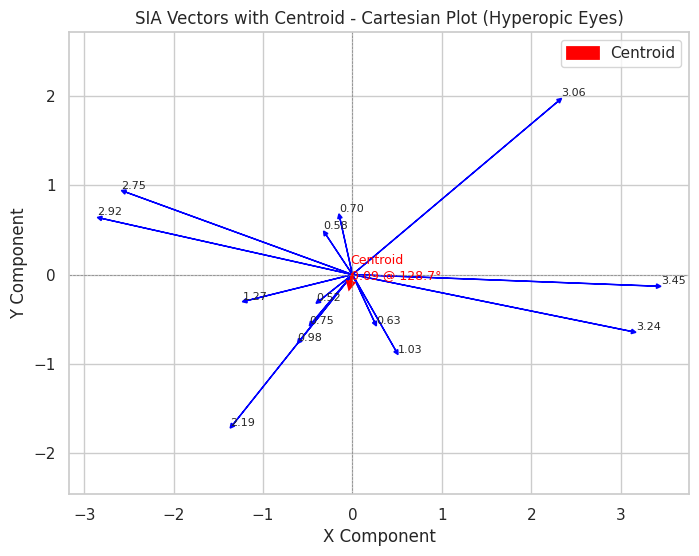

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate centroid (mean of sia_x and sia_y)
centroid_x = hyperopic_df['sia_x'].mean()
centroid_y = hyperopic_df['sia_y'].mean()

# Calculate magnitude and axis of centroid
centroid_magnitude = np.sqrt(centroid_x**2 + centroid_y**2)
centroid_axis = (np.rad2deg(np.arctan2(centroid_y, centroid_x)) / 2) % 180

# Plot setup
plt.figure(figsize=(8, 6))
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)

# Plot each SIA vector
for i in range(len(hyperopic_df)):
    x = hyperopic_df['sia_x'].iloc[i]
    y = hyperopic_df['sia_y'].iloc[i]
    plt.arrow(0, 0, x, y, head_width=0.05, head_length=0.05, fc='blue', ec='blue', length_includes_head=True)
    plt.text(x, y, f"{hyperopic_df['SIA_magnitude'].iloc[i]:.2f}", fontsize=8, ha='left', va='bottom')

# Plot centroid vector
plt.arrow(0, 0, centroid_x, centroid_y, color='red', linewidth=2, head_width=0.07, head_length=0.07, label='Centroid')
plt.text(centroid_x, centroid_y, f"Centroid\n{centroid_magnitude:.2f} @ {centroid_axis:.1f}°",
         color='red', fontsize=9, ha='left', va='bottom')

# Final touches
plt.xlabel('X Component')
plt.ylabel('Y Component')
plt.title('SIA Vectors with Centroid - Cartesian Plot (Hyperopic Eyes)')
plt.grid(True)
plt.axis('equal')
plt.legend()
plt.show()


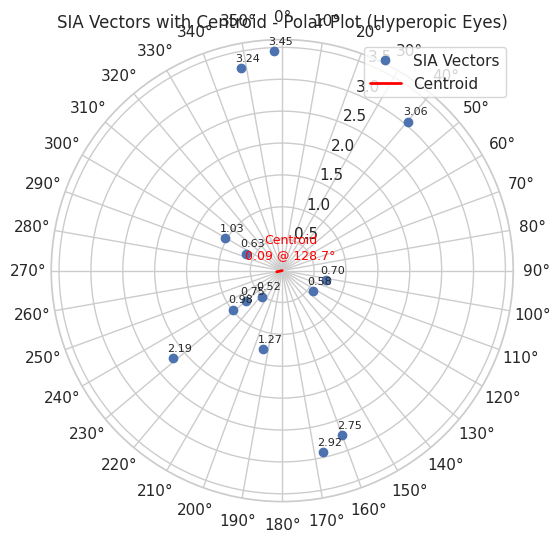

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# Convert SIA axis to radians for polar plot
theta = np.deg2rad(hyperopic_df['SIA_axis'] * 2)
r = hyperopic_df['SIA_magnitude']

# Calculate centroid (mean of Cartesian components)
centroid_x = hyperopic_df['sia_x'].mean()
centroid_y = hyperopic_df['sia_y'].mean()

# Convert centroid to polar (double angle)
centroid_magnitude = np.sqrt(centroid_x**2 + centroid_y**2)
centroid_axis = (np.rad2deg(np.arctan2(centroid_y, centroid_x)) / 2) % 180
centroid_theta = np.deg2rad(centroid_axis * 2)

# Create polar plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, polar=True)

# Plot individual vectors
ax.plot(theta, r, 'bo', label='SIA Vectors')

# Annotate individual points
for i in range(len(hyperopic_df)):
    ax.annotate(f"{r.iloc[i]:.2f}",
                (theta.iloc[i], r.iloc[i]),
                textcoords="offset points", xytext=(5, 5), ha='center', fontsize=8)

# Plot centroid vector
ax.plot([0, centroid_theta], [0, centroid_magnitude], color='red', linewidth=2, label='Centroid')
ax.annotate(f"Centroid\n{centroid_magnitude:.2f} @ {centroid_axis:.1f}°",
            (centroid_theta, centroid_magnitude),
            textcoords="offset points", xytext=(10, 10), ha='center', fontsize=9, color='red')

# Polar plot settings
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_thetagrids(range(0, 360, 10))

# Final touches
ax.set_title("SIA Vectors with Centroid - Polar Plot (Hyperopic Eyes)", va='bottom')
ax.legend()
plt.show()


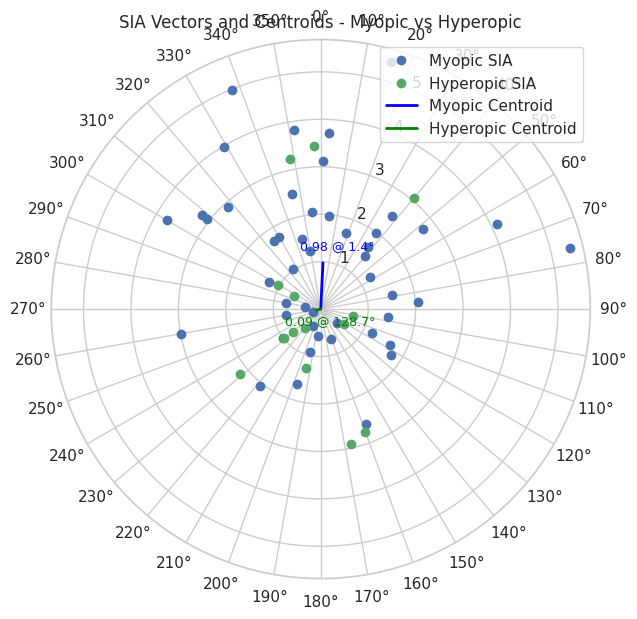

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# === Myopic Data ===
theta_myopic = np.deg2rad(myopic_df['SIA_axis'] * 2)
r_myopic = myopic_df['SIA_magnitude']
centroid_x_myopic = myopic_df['sia_x'].mean()
centroid_y_myopic = myopic_df['sia_y'].mean()
centroid_mag_myopic = np.sqrt(centroid_x_myopic**2 + centroid_y_myopic**2)
centroid_axis_myopic = (np.rad2deg(np.arctan2(centroid_y_myopic, centroid_x_myopic)) / 2) % 180
centroid_theta_myopic = np.deg2rad(centroid_axis_myopic * 2)

# === Hyperopic Data ===
theta_hyper = np.deg2rad(hyperopic_df['SIA_axis'] * 2)
r_hyper = hyperopic_df['SIA_magnitude']
centroid_x_hyper = hyperopic_df['sia_x'].mean()
centroid_y_hyper = hyperopic_df['sia_y'].mean()
centroid_mag_hyper = np.sqrt(centroid_x_hyper**2 + centroid_y_hyper**2)
centroid_axis_hyper = (np.rad2deg(np.arctan2(centroid_y_hyper, centroid_x_hyper)) / 2) % 180
centroid_theta_hyper = np.deg2rad(centroid_axis_hyper * 2)

# === Polar Plot ===
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, polar=True)

# Plot myopic vectors
ax.plot(theta_myopic, r_myopic, 'bo', label='Myopic SIA')

# Plot hyperopic vectors
ax.plot(theta_hyper, r_hyper, 'go', label='Hyperopic SIA')

# Plot centroid vectors
ax.plot([0, centroid_theta_myopic], [0, centroid_mag_myopic], color='blue', linewidth=2, label='Myopic Centroid')
ax.plot([0, centroid_theta_hyper], [0, centroid_mag_hyper], color='green', linewidth=2, label='Hyperopic Centroid')

# Annotate centroids
ax.annotate(f"{centroid_mag_myopic:.2f} @ {centroid_axis_myopic:.1f}°",
            (centroid_theta_myopic, centroid_mag_myopic),
            textcoords="offset points", xytext=(10, 10), ha='center', fontsize=9, color='blue')

ax.annotate(f"{centroid_mag_hyper:.2f} @ {centroid_axis_hyper:.1f}°",
            (centroid_theta_hyper, centroid_mag_hyper),
            textcoords="offset points", xytext=(10, -10), ha='center', fontsize=9, color='green')

# Polar settings
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_thetagrids(range(0, 360, 10))
ax.set_title('SIA Vectors and Centroids - Myopic vs Hyperopic', va='bottom')
ax.legend(loc='upper right')
plt.show()


In [48]:
import numpy as np

# Step 1: Compute preoperative cylinder
mixed_df['preopcyl'] = mixed_df['KV'] - mixed_df['KH']
mixed_df['postopcyl'] = mixed_df['CYL']

# Step 2: Convert axis to double-angle (in radians)
mixed_df['pre_theta'] = np.deg2rad(mixed_df['AX'] * 2)
mixed_df['post_theta'] = np.deg2rad(mixed_df['AXIS'] * 2)

# Step 3: Convert to Cartesian coordinates (X, Y)
mixed_df['pre_x'] = mixed_df['preopcyl'] * np.cos(mixed_df['pre_theta'])
mixed_df['pre_y'] = mixed_df['preopcyl'] * np.sin(mixed_df['pre_theta'])

mixed_df['post_x'] = mixed_df['postopcyl'] * np.cos(mixed_df['post_theta'])
mixed_df['post_y'] = mixed_df['postopcyl'] * np.sin(mixed_df['post_theta'])

# Step 4: Calculate SIA vector components
mixed_df['sia_x'] = mixed_df['post_x'] - mixed_df['pre_x']
mixed_df['sia_y'] = mixed_df['post_y'] - mixed_df['pre_y']

# Step 5: Compute magnitude and axis of SIA
mixed_df['SIA_magnitude'] = np.sqrt(mixed_df['sia_x']**2 + mixed_df['sia_y']**2)
mixed_df['SIA_axis'] = (np.rad2deg(np.arctan2(mixed_df['sia_y'], mixed_df['sia_x'])) / 2) % 180

# Step 6: Round results for display
mixed_df['SIA_magnitude'] = mixed_df['SIA_magnitude'].round(2)
mixed_df['SIA_axis'] = mixed_df['SIA_axis'].round(1)

# Step 7: Display results
print(mixed_df[['SIA_magnitude', 'SIA_axis']])


     SIA_magnitude  SIA_axis
0             1.79      37.2
1             3.50     170.0
5             2.91     175.1
6             3.95      78.4
8             3.37     139.2
..             ...       ...
149           1.11     148.9
155           2.50     170.0
159           4.48      57.3
163           4.25       5.0
167           2.61      92.7

[69 rows x 2 columns]


/tmp/ipython-input-1263300559.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mixed_df['preopcyl'] = mixed_df['KV'] - mixed_df['KH']
/tmp/ipython-input-1263300559.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mixed_df['postopcyl'] = mixed_df['CYL']
/tmp/ipython-input-1263300559.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pand

In [49]:
mixed_df

,KH,KV,AX,SPH,CYL,AXIS,Classification,preopcyl,postopcyl,pre_theta,post_theta,pre_x,pre_y,post_x,post_y,sia_x,sia_y,SIA_magnitude,SIA_axis
0,46.50,47.25,155,0.25,-1.50,115.0,Mixed Astigmatism,0.75,-1.50,5.410521,4.014257,0.482091,-0.574533,9.641814e-01,1.149067e+00,0.482091,1.723600,1.79,37.2
1,46.75,48.00,80,0.75,-2.25,80.0,Mixed Astigmatism,1.25,-2.25,2.792527,2.792527,-1.174616,0.427525,2.114308e+00,-7.695453e-01,3.288924,-1.197071,3.50,170.0
5,42.50,43.50,75,2,-2.00,90.0,Mixed Astigmatism,1.00,-2.00,2.617994,3.141593,-0.866025,0.500000,2.000000e+00,-2.449294e-16,2.866025,-0.500000,2.91,175.1
6,43.50,44.00,20,-0.5,3.75,75.0,Mixed Astigmatism,0.50,3.75,0.698132,2.617994,0.383022,0.321394,-3.247595e+00,1.875000e+00,-3.630617,1.553606,3.95,78.4
8,44.75,45.25,85,1.5,-3.25,45.0,Mixed Astigmatism,0.50,-3.25,2.967060,1.570796,-0.492404,0.086824,-1.990051e-16,-3.250000e+00,0.492404,-3.336824,3.37,139.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149,45.25,45.50,30,2.5,-1.00,65.0,Mixed Astigmatism,0.25,-1.00,1.047198,2.268928,0.125000,0.216506,6.427876e-01,-7.660444e-01,0.517788,-0.982551,1.11,148.9
155,44.25,45.75,80,1.25,-1.00,80.0,Mixed Astigmatism,1.50,-1.00,2.792527,2.792527,-1.409539,0.513030,9.396926e-01,-3.420201e-01,2.349232,-0.855050,2.50,170.0
159,41.75,43.50,160,-2.25,3.00,50.0,Mixed Astigmatism,1.75,3.00,5.585054,1.745329,1.340578,-1.124878,-5.209445e-01,2.954423e+00,-1.861522,4.079302,4.48,57.3
163,45.25,45.25,180,1.75,-4.25,95.0,Mixed Astigmatism,0.00,-4.25,6.283185,3.316126,0.000000,-0.000000,4.185433e+00,7.380048e-01,4.185433,0.738005,4.25,5.0


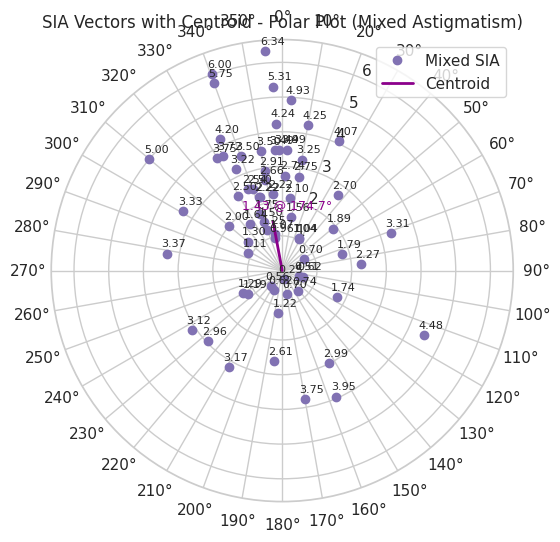

In [50]:
import matplotlib.pyplot as plt
import numpy as np

# Convert SIA axis to radians
theta_mixed = np.deg2rad(mixed_df['SIA_axis'] * 2)
r_mixed = mixed_df['SIA_magnitude']

# Calculate centroid
centroid_x = mixed_df['sia_x'].mean()
centroid_y = mixed_df['sia_y'].mean()
centroid_mag = np.sqrt(centroid_x**2 + centroid_y**2)
centroid_axis = (np.rad2deg(np.arctan2(centroid_y, centroid_x)) / 2) % 180
centroid_theta = np.deg2rad(centroid_axis * 2)

# Create polar plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, polar=True)

# Plot individual SIA vectors
ax.plot(theta_mixed, r_mixed, 'mo', label='Mixed SIA')

# Annotate each point
for i in range(len(mixed_df)):
    ax.annotate(f"{r_mixed.iloc[i]:.2f}",
                (theta_mixed.iloc[i], r_mixed.iloc[i]),
                textcoords="offset points", xytext=(5, 5), ha='center', fontsize=8)

# Plot centroid vector
ax.plot([0, centroid_theta], [0, centroid_mag], color='darkmagenta', linewidth=2, label='Centroid')
ax.annotate(f"{centroid_mag:.2f} @ {centroid_axis:.1f}°",
            (centroid_theta, centroid_mag),
            textcoords="offset points", xytext=(10, 10), fontsize=9, color='darkmagenta', ha='center')

# Polar plot settings
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_thetagrids(range(0, 360, 10))
ax.set_title("SIA Vectors with Centroid - Polar Plot (Mixed Astigmatism)", va='bottom')
ax.legend()
plt.show()


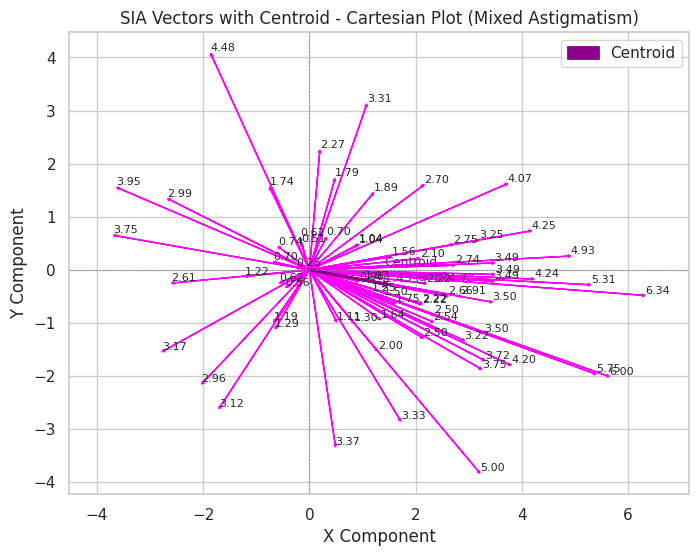

In [51]:
# Create Cartesian plot
plt.figure(figsize=(8, 6))
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)

# Plot each SIA vector from origin
for i in range(len(mixed_df)):
    x = mixed_df['sia_x'].iloc[i]
    y = mixed_df['sia_y'].iloc[i]
    plt.arrow(0, 0, x, y, head_width=0.05, head_length=0.05, fc='magenta', ec='magenta', length_includes_head=True)
    plt.text(x, y, f"{mixed_df['SIA_magnitude'].iloc[i]:.2f}", fontsize=8, ha='left', va='bottom')

# Plot centroid
plt.arrow(0, 0, centroid_x, centroid_y, color='darkmagenta', linewidth=2, head_width=0.07, head_length=0.07, label='Centroid')
plt.text(centroid_x, centroid_y, f"Centroid\n{centroid_mag:.2f} @ {centroid_axis:.1f}°",
         color='darkmagenta', fontsize=9, ha='left', va='bottom')

# Final touches
plt.xlabel('X Component')
plt.ylabel('Y Component')
plt.title('SIA Vectors with Centroid - Cartesian Plot (Mixed Astigmatism)')
plt.grid(True)
plt.axis('equal')
plt.legend()
plt.show()


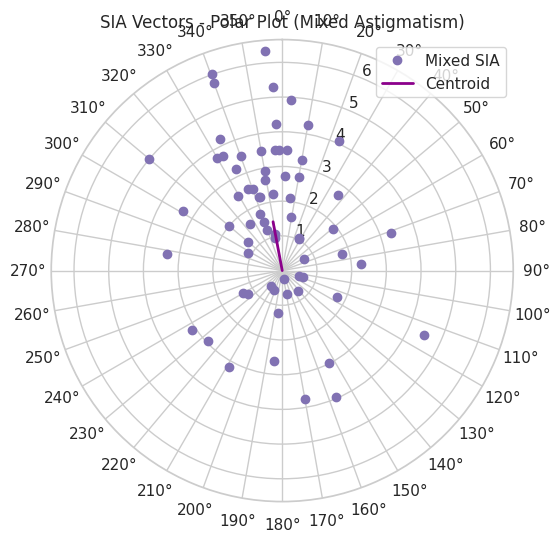

In [52]:
import matplotlib.pyplot as plt
import numpy as np

# Convert SIA axis to radians
theta_mixed = np.deg2rad(mixed_df['SIA_axis'] * 2)
r_mixed = mixed_df['SIA_magnitude']

# Calculate centroid
centroid_x = mixed_df['sia_x'].mean()
centroid_y = mixed_df['sia_y'].mean()
centroid_mag = np.sqrt(centroid_x**2 + centroid_y**2)
centroid_axis = (np.rad2deg(np.arctan2(centroid_y, centroid_x)) / 2) % 180
centroid_theta = np.deg2rad(centroid_axis * 2)

# Create polar plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, polar=True)

# Plot SIA vectors (no annotations)
ax.plot(theta_mixed, r_mixed, 'mo', label='Mixed SIA')

# Plot centroid vector (no label text)
ax.plot([0, centroid_theta], [0, centroid_mag], color='darkmagenta', linewidth=2, label='Centroid')

# Polar settings
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_thetagrids(range(0, 360, 10))
ax.set_title("SIA Vectors - Polar Plot (Mixed Astigmatism)", va='bottom')
ax.legend()
plt.show()


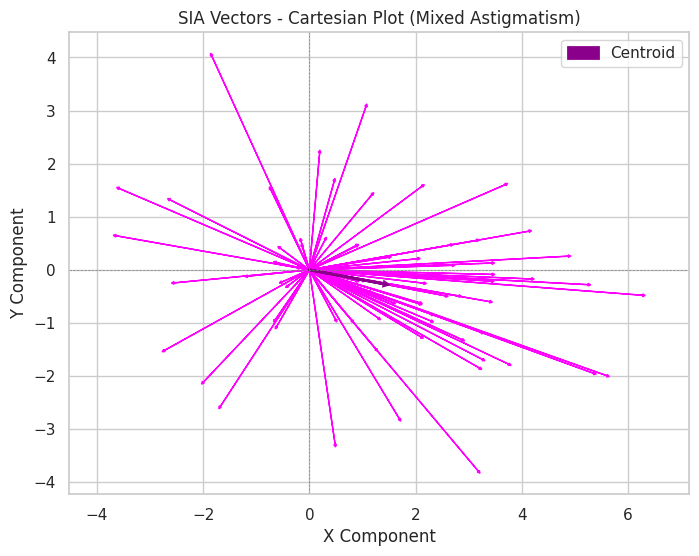

In [53]:
# Create Cartesian plot
plt.figure(figsize=(8, 6))
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)

# Plot each SIA vector from origin (no labels)
for i in range(len(mixed_df)):
    x = mixed_df['sia_x'].iloc[i]
    y = mixed_df['sia_y'].iloc[i]
    plt.arrow(0, 0, x, y, head_width=0.05, head_length=0.05,
              fc='magenta', ec='magenta', length_includes_head=True)

# Plot centroid (no label)
plt.arrow(0, 0, centroid_x, centroid_y, color='darkmagenta',
          linewidth=2, head_width=0.07, head_length=0.07, label='Centroid')

# Final touches
plt.xlabel('X Component')
plt.ylabel('Y Component')
plt.title('SIA Vectors - Cartesian Plot (Mixed Astigmatism)')
plt.grid(True)
plt.axis('equal')
plt.legend()
plt.show()


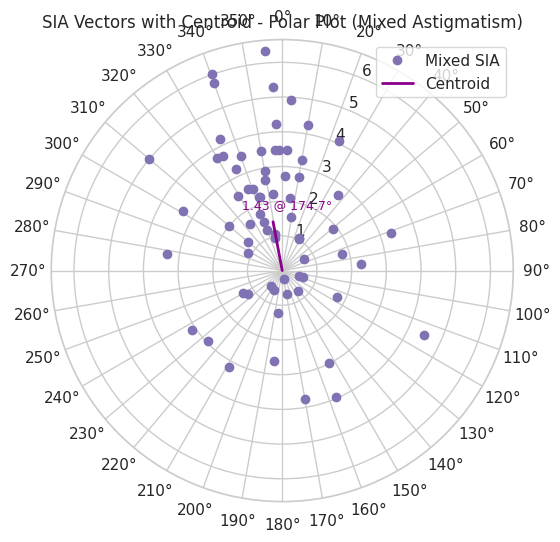

In [54]:
import matplotlib.pyplot as plt
import numpy as np

# Convert SIA axis to radians
theta_mixed = np.deg2rad(mixed_df['SIA_axis'] * 2)
r_mixed = mixed_df['SIA_magnitude']

# Calculate centroid
centroid_x = mixed_df['sia_x'].mean()
centroid_y = mixed_df['sia_y'].mean()
centroid_mag = np.sqrt(centroid_x**2 + centroid_y**2)
centroid_axis = (np.rad2deg(np.arctan2(centroid_y, centroid_x)) / 2) % 180
centroid_theta = np.deg2rad(centroid_axis * 2)

# Polar plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, polar=True)

# Plot SIA vectors (no labels)
ax.plot(theta_mixed, r_mixed, 'mo', label='Mixed SIA')

# Plot centroid vector
ax.plot([0, centroid_theta], [0, centroid_mag], color='darkmagenta', linewidth=2, label='Centroid')

# Annotate centroid only
ax.annotate(f"{centroid_mag:.2f} @ {centroid_axis:.1f}°",
            (centroid_theta, centroid_mag),
            textcoords="offset points", xytext=(10, 10), fontsize=9, color='darkmagenta', ha='center')

# Polar settings
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_thetagrids(range(0, 360, 10))
ax.set_title("SIA Vectors with Centroid - Polar Plot (Mixed Astigmatism)", va='bottom')
ax.legend()
plt.show()


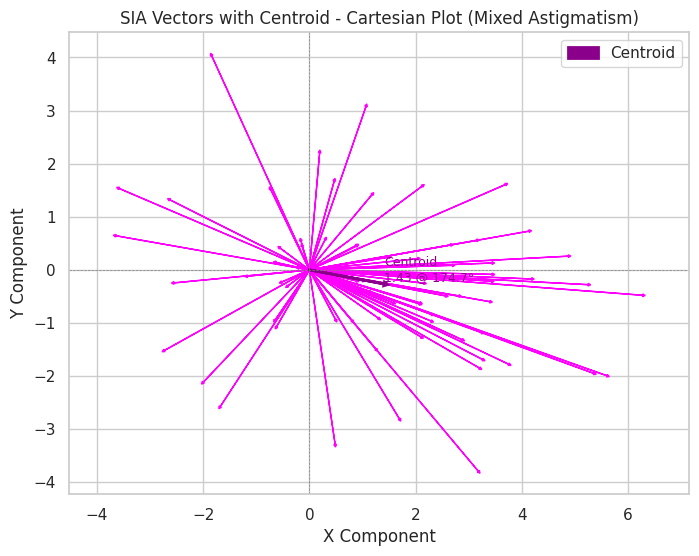

In [55]:
# Cartesian plot
plt.figure(figsize=(8, 6))
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)

# Plot vectors (no labels)
for i in range(len(mixed_df)):
    x = mixed_df['sia_x'].iloc[i]
    y = mixed_df['sia_y'].iloc[i]
    plt.arrow(0, 0, x, y, head_width=0.05, head_length=0.05,
              fc='magenta', ec='magenta', length_includes_head=True)

# Plot centroid vector
plt.arrow(0, 0, centroid_x, centroid_y, color='darkmagenta',
          linewidth=2, head_width=0.07, head_length=0.07, label='Centroid')

# Annotate centroid only
plt.text(centroid_x, centroid_y,
         f"Centroid\n{centroid_mag:.2f} @ {centroid_axis:.1f}°",
         color='darkmagenta', fontsize=9, ha='left', va='bottom')

# Final plot settings
plt.xlabel('X Component')
plt.ylabel('Y Component')
plt.title('SIA Vectors with Centroid - Cartesian Plot (Mixed Astigmatism)')
plt.grid(True)
plt.axis('equal')
plt.legend()
plt.show()


In [56]:
df.columns

Index(['IP NUMBER ', 'NAME ', 'AGE', 'SEX', 'DIAGNOSIS', 'KH', 'KV', 'AX',
       'AL', 'ACD', 'LT', 'V/A PRE OP', 'POD 1 DAY V/A', 'SPH', 'CYL', 'AXIS',
       'POD 1 DAY  AR ', 'POD 6 WEEK V/A ', 'SPH ', 'CYL.1', 'AXIS.1',
       'POD 6 WEEK   AR ', 'POD 3 MONTH V/A', 'SPH.1', 'CYL ', 'AXIS.2',
       'POD 3  MONTH    AR'],
      dtype='object')

In [59]:
wk6AR = df[['KH', 'KV', 'AX','SPH ', 'CYL.1', 'AXIS.1']]
wk6AR

,KH,KV,AX,SPH,CYL.1,AXIS.1
0,46.50,47.25,155,0.25,-1.25,100.0
1,46.75,48.00,80,0.75,-2.00,90.0
2,44.00,44.25,20,-1.5,-1.00,140.0
3,45.25,45.75,120,-0.5,-0.75,140.0
4,45.50,47.00,80,0.25,2.25,85.0
...,...,...,...,...,...,...
169,45.00,46.25,165,-2,-2.50,110.0
170,41.00,42.50,85,-2,-1.25,90.0
171,44.75,45.75,75,-2.5,-4.25,10.0
172,44.75,45.25,170,-1,3.25,150.0


In [60]:
wk6AR.shape, wk6AR.columns

((174, 6),
 Index(['KH', 'KV', 'AX', 'SPH ', 'CYL.1', 'AXIS.1'], dtype='object'))

In [61]:
wk6AR.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 174 entries, 0 to 173
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   KH      174 non-null    float64
 1   KV      174 non-null    float64
 2   AX      174 non-null    int64  
 3   SPH     173 non-null    object 
 4   CYL.1   171 non-null    float64
 5   AXIS.1  171 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 8.3+ KB


In [62]:
wk6AR.isnull().sum()

,0
KH,0
KV,0
AX,0
SPH,1
CYL.1,3
AXIS.1,3


In [66]:
wk6AR = wk6AR.dropna()
wk6AR.isnull().sum()

,0
KH,0
KV,0
AX,0
SPH,0
CYL.1,0
AXIS.1,0


In [67]:
wk6AR.shape, wk6AR.columns

((171, 6),
 Index(['KH', 'KV', 'AX', 'SPH ', 'CYL.1', 'AXIS.1'], dtype='object'))

In [69]:
wk6AR

,KH,KV,AX,SPH,CYL.1,AXIS.1
0,46.50,47.25,155,0.25,-1.25,100.0
1,46.75,48.00,80,0.75,-2.00,90.0
2,44.00,44.25,20,-1.5,-1.00,140.0
3,45.25,45.75,120,-0.5,-0.75,140.0
4,45.50,47.00,80,0.25,2.25,85.0
...,...,...,...,...,...,...
169,45.00,46.25,165,-2,-2.50,110.0
170,41.00,42.50,85,-2,-1.25,90.0
171,44.75,45.75,75,-2.5,-4.25,10.0
172,44.75,45.25,170,-1,3.25,150.0
